In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data/stud.csv')

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.shape

(1000, 8)

#### Missing Value

In [5]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [6]:
#no missing values in the dataset

In [7]:
#check for duplicate values
df.duplicated().sum()

np.int64(0)

In [8]:
# no duplicate values in the dataset

In [9]:
#checking the datatype
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [10]:
df.sample()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
609,female,group B,associate's degree,standard,none,58,63,65


In [11]:
#checking the unique values of each column
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [12]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [13]:
# unique values of each columns
for col in df.columns[:5]:
    print(f"Unique values in {col}: {df[col].unique()} \n")

Unique values in gender: <StringArray>
['female', 'male']
Length: 2, dtype: str 

Unique values in race_ethnicity: <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str 

Unique values in parental_level_of_education: <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str 

Unique values in lunch: <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str 

Unique values in test_preparation_course: <StringArray>
['none', 'completed']
Length: 2, dtype: str 



In [14]:
# classifying numerical and catagorical features:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns
print(num_cols, "\n", cat_cols)

Index(['math_score', 'reading_score', 'writing_score'], dtype='str') 
 Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course'],
      dtype='str')


## Feature Engineering

In [15]:
#total_score and percentage
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['percentage'] = np.round(df['total_score'] / 3,2)
df.head(1)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,percentage
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.67


In [16]:
#number of students with the full marks.
print(f"Number of students with full marks in every subjects: {df[df['percentage'] == 100].shape[0]} \n")
print(f"Number of students with full marks in reading_score: {df[df['reading_score']==100].shape[0]} ")
print(f"Number of students with full marks in writing_score: {df[df['writing_score']==100].shape[0]} ")
print(f"Number of students with full marks in math_score: {df[df['math_score']==100].shape[0]} ")

Number of students with full marks in every subjects: 3 

Number of students with full marks in reading_score: 17 
Number of students with full marks in writing_score: 14 
Number of students with full marks in math_score: 7 


In [17]:
#number of students who passed:
print(f"Number of students who passed: {df[(df['percentage'] >= 40) & (df['reading_score'] >= 40) & (df['writing_score'] >= 40) & (df['math_score'] >= 40)].shape[0]} \n")

#number of students who failed:
print("Total number of students who failed:", df.shape[0] - df[(df['percentage'] >= 40) & (df['reading_score'] >= 40) & (df['writing_score'] >= 40) & (df['math_score'] >= 40)].shape[0])

#number of students who failed in each subjects:
print(f"Number of students who failed in reading_score: {df[df['reading_score'] < 40].shape[0]} ")
print(f"Number of students who failed in writing_score: {df[df['writing_score'] < 40].shape[0]} ")
print(f"Number of students who failed in math_score: {df[df['math_score'] < 40].shape[0]} ")

Number of students who passed: 949 

Total number of students who failed: 51
Number of students who failed in reading_score: 26 
Number of students who failed in writing_score: 32 
Number of students who failed in math_score: 40 


Students perform the best in reading section and the worst in math section.

## Data Visualization

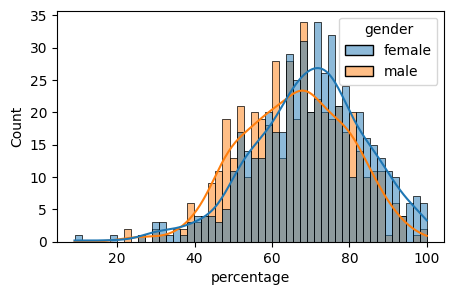

In [18]:
plt.figure(figsize=(5,3))
sns.histplot(x='percentage', data=df, hue='gender', bins=50, kde=True)
plt.show()

Female score higher marks than male.

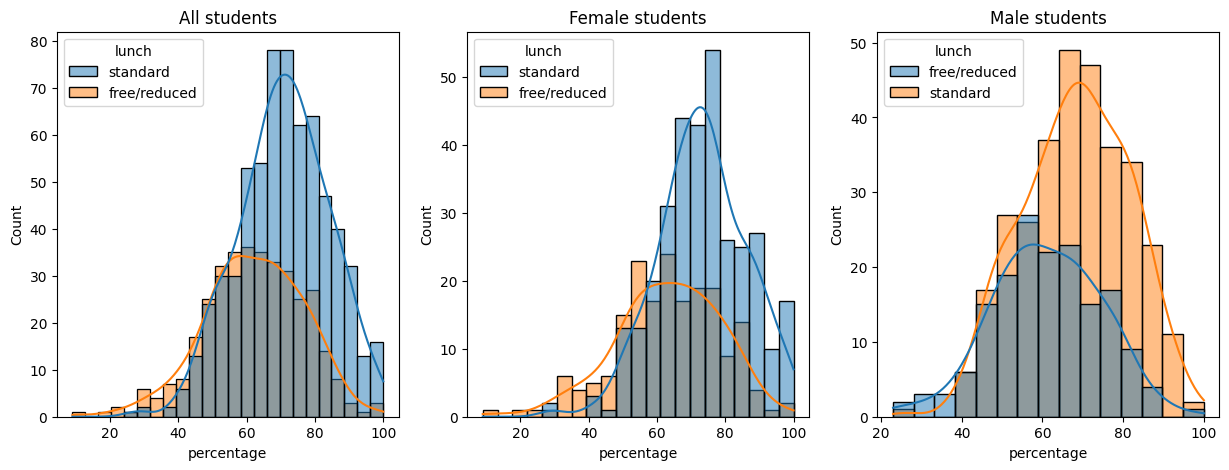

In [19]:
fig, axes = plt.subplots(1,3, figsize=(15,5))

sns.histplot(x='percentage',data=df, hue='lunch', ax=axes[0],kde=True)
axes[0].set_title('All students')
sns.histplot(x='percentage',data=df[df['gender']=='female'], hue='lunch', ax=axes[1],kde=True)
axes[1].set_title('Female students')
sns.histplot(x='percentage',data=df[df['gender']=='male'], hue='lunch', ax=axes[2],kde=True)
axes[2].set_title('Male students')
plt.show()

The student who takes standard lunch tends to score higher marks than that of free/reduced.

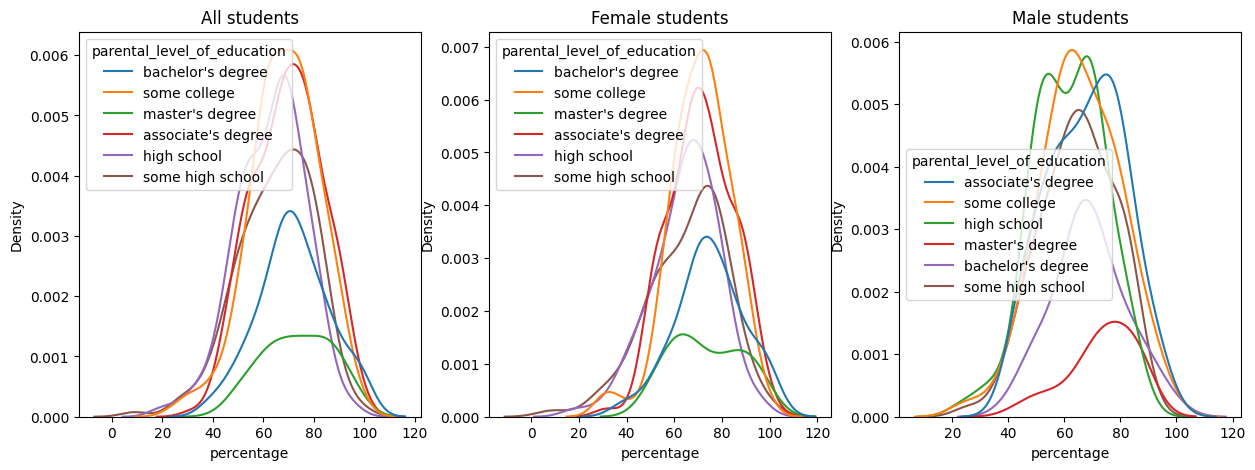

In [20]:
fig, axes = plt.subplots(1,3, figsize=(15,5))

sns.kdeplot(x='percentage',data=df, hue='parental_level_of_education', ax=axes[0] )
axes[0].set_title('All students')
sns.kdeplot(x='percentage',data=df[df['gender']=='female'], hue='parental_level_of_education', ax=axes[1] )
axes[1].set_title('Female students')
sns.kdeplot(x='percentage',data=df[df['gender']=='male'], hue='parental_level_of_education', ax=axes[2] )
axes[2].set_title('Male students')
plt.show()

The students having parent either master or bachelor level of education tend to score higher.
The students having parent either high school or some high school level of education tend to score lower.


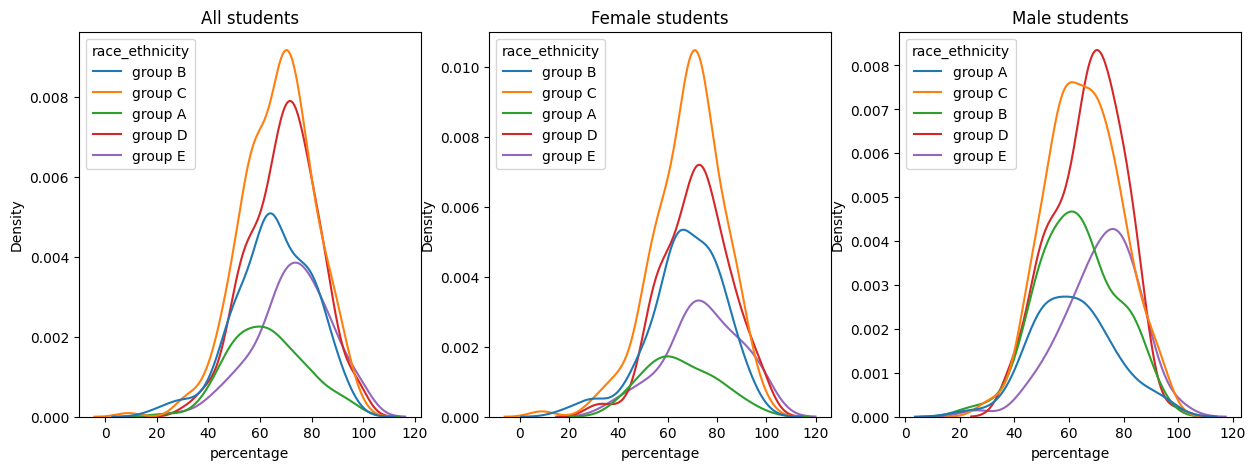

In [21]:
fig, axes = plt.subplots(1,3, figsize=(15,5))
sns.kdeplot(x='percentage',data=df, hue='race_ethnicity', ax=axes[0] )
axes[0].set_title('All students')

sns.kdeplot(x='percentage',data=df[df['gender']=='female'], hue='race_ethnicity', ax=axes[1] )
axes[1].set_title('Female students')

sns.kdeplot(x='percentage',data=df[df['gender']=='male'], hue='race_ethnicity', ax=axes[2] )
axes[2].set_title('Male students')

plt.show()

Group E is performing the best and Group A is performing the worst:
E>D>C>B>A

In [22]:
# analyzing the total number of students falling in each percentage range
bins = [0, 40, 60, 80, 100]
labels = ['0-40', '40-60', '60-80', '80-100']
df['percentage_range'] = pd.cut(df['percentage'], bins=bins, labels=labels, include_lowest=True)
percentage_range_counts = df['percentage_range'].value_counts().sort_index()
print(percentage_range_counts) 

percentage_range
0-40       32
40-60     261
60-80     513
80-100    194
Name: count, dtype: int64


### Multivariate analysis

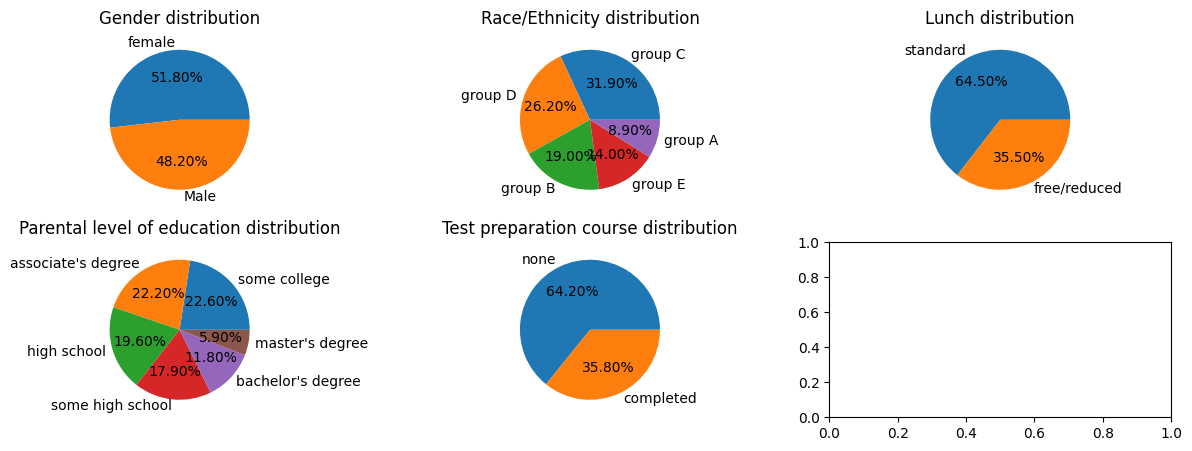

In [23]:
fig, axes = plt.subplots(2,3, figsize=(15,5))

# percetage of male and female:
df['gender'].value_counts().plot.pie(labels = ['female','Male'], autopct='%.2f%%', ax=axes[0,0])
axes[0,0].set_title('Gender distribution')

#perentaage of race/ethnicity
df['race_ethnicity'].value_counts().plot.pie(autopct='%.2f%%', ax=axes[0,1])
axes[0,1].set_title('Race/Ethnicity distribution')

#percentage of lunch
df['lunch'].value_counts().plot.pie(autopct='%.2f%%', ax=axes[0,2])
axes[0,2].set_title('Lunch distribution')

#percentage of parental level of education
df['parental_level_of_education'].value_counts().plot.pie(autopct='%.2f%%', ax=axes[1,0])
axes[1,0].set_title('Parental level of education distribution')

#percentage of test preparation course
df['test_preparation_course'].value_counts().plot.pie(autopct='%.2f%%', ax=axes[1,1])
axes[1,1].set_title('Test preparation course distribution')


plt.show()


### Feature Wise Visulatization

### 1. Gender

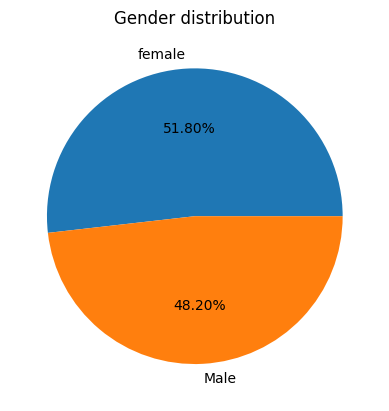

In [24]:
plt.pie(df['gender'].value_counts(), labels = ['female','Male'], autopct='%.2f%%')
plt.title('Gender distribution')
plt.show()

balanced data of female and male

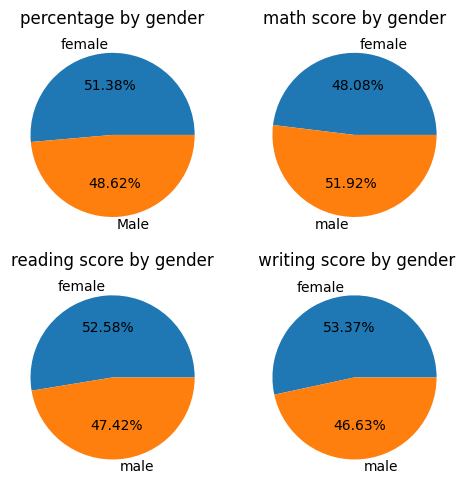

In [25]:
fig, axes = plt.subplots(2,2, figsize=(5,5))

axes[0,0].pie(df.groupby('gender')['percentage'].mean(), labels = ['female','Male'], autopct='%.2f%%')
axes[0,0].set_title('percentage by gender')

axes[0,1].pie(df.groupby('gender')['math_score'].mean(), labels = ['female','male'], autopct='%.2f%%')
axes[0,1].set_title('math score by gender')

axes[1,0].pie(df.groupby('gender')['reading_score'].mean(), labels = ['female','male'], autopct='%.2f%%')
axes[1,0].set_title('reading score by gender')

axes[1,1].pie(df.groupby('gender')['writing_score'].mean(), labels = ['female','male'], autopct='%.2f%%')
axes[1,1].set_title(' writing score by gender')
plt.tight_layout()
plt.show()

- males done well in math section only.
- females done well in reading, writing and overall.

### RACE/ETHNICITY COLUMN

In [26]:
df['race_ethnicity'].value_counts()

race_ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

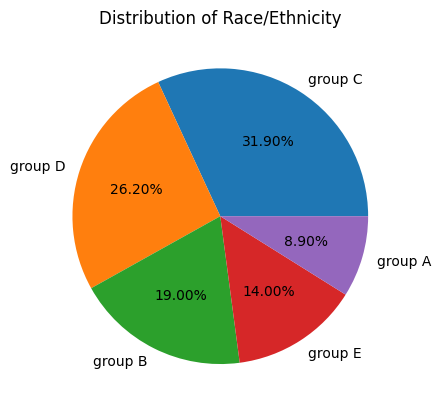

In [27]:
plt.pie(df['race_ethnicity'].value_counts(), labels=df['race_ethnicity'].value_counts().index, autopct='%.2f%%')
plt.title('Distribution of Race/Ethnicity')
plt.show()

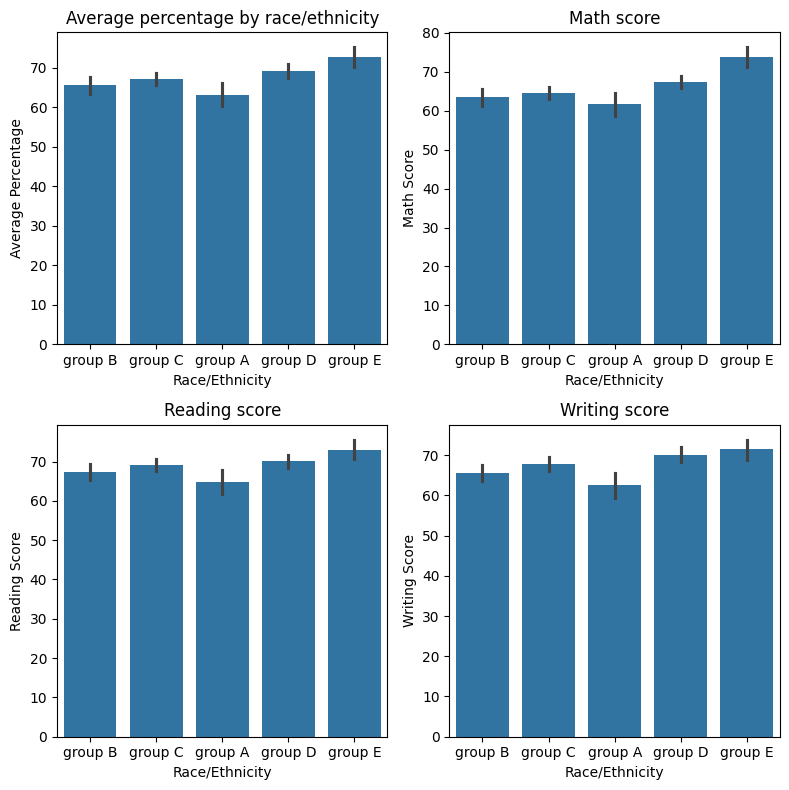

In [28]:
fig, axes = plt.subplots(2,2, figsize=(8,8))

sns.barplot(x='race_ethnicity', y='percentage', data=df, ax=axes[0,0])
axes[0,0].set_title('Average percentage by race/ethnicity')
axes[0,0].set_xlabel('Race/Ethnicity')
axes[0,0].set_ylabel('Average Percentage')

sns.barplot(x='race_ethnicity', y='math_score', data=df, ax=axes[0,1])
axes[0,1].set_title('Math score')
axes[0,1].set_xlabel('Race/Ethnicity')
axes[0,1].set_ylabel('Math Score')

sns.barplot(x='race_ethnicity', y='reading_score', data=df, ax=axes[1,0])
axes[1,0].set_title('Reading score')
axes[1,0].set_xlabel('Race/Ethnicity')
axes[1,0].set_ylabel('Reading Score')

sns.barplot(x='race_ethnicity', y='writing_score', data=df, ax=axes[1,1])
axes[1,1].set_title('Writing score')
axes[1,1].set_xlabel('Race/Ethnicity')
axes[1,1].set_ylabel('Writing Score')

plt.tight_layout()
plt.show()


group E score highest marks and group A score lowest marks in every subject and average.

### Parent level of education 

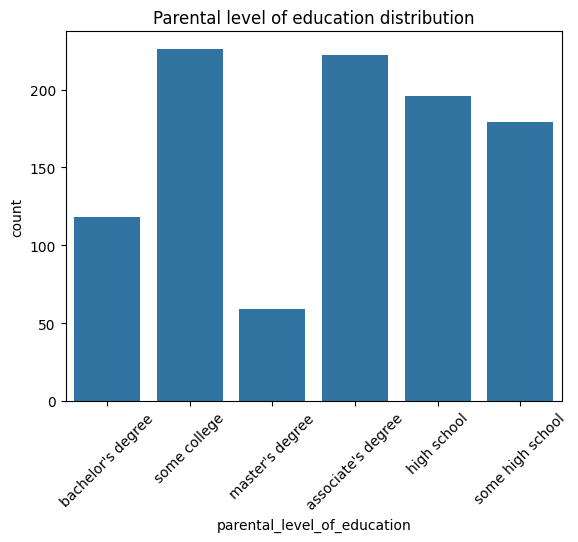

In [34]:
sns.countplot(x='parental_level_of_education', data=df)
plt.title('Parental level of education distribution')
plt.xticks(rotation=45)
plt.show()

most of the parents have some college and associate's degree

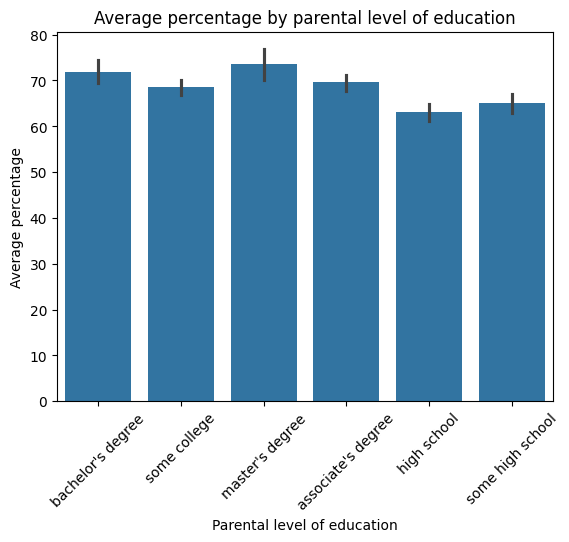

In [35]:
sns.barplot(x='parental_level_of_education', y='percentage', data=df)
plt.title('Average percentage by parental level of education')
plt.xlabel('Parental level of education')
plt.ylabel('Average percentage')
plt.xticks(rotation=45)
plt.show()

The students whose parents have a master's degree have the highest average percentage, while those whose parents have some high school education have the lowest average percentage.

### Lunch

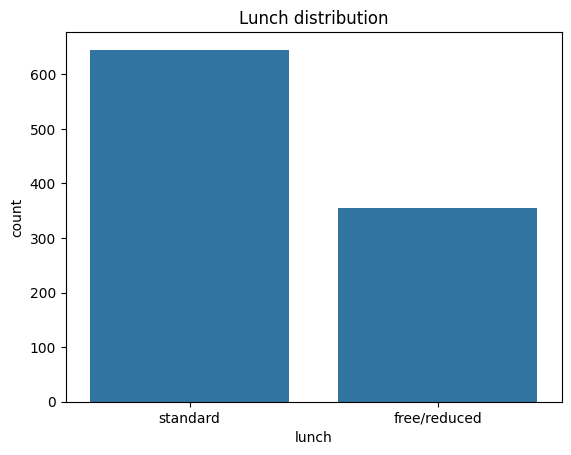

In [36]:
sns.countplot(x='lunch', data=df)
plt.title('Lunch distribution')
plt.show()

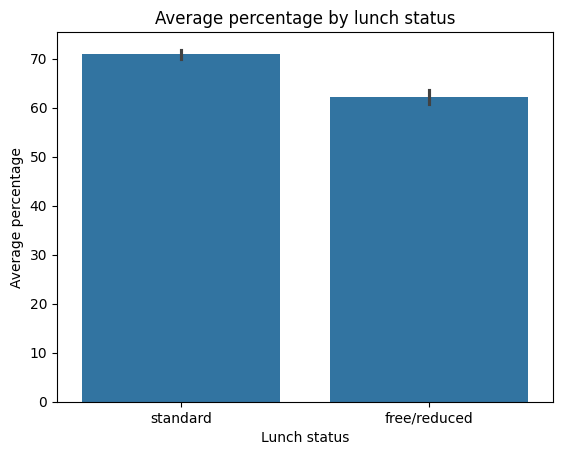

In [37]:
sns.barplot(x='lunch', y='percentage', data=df)
plt.title('Average percentage by lunch status')
plt.xlabel('Lunch status')
plt.ylabel('Average percentage')
plt.show()

the student who takes standard lunch has higher percentage than the student who takes free/reduced lunch.

### Test Preparation

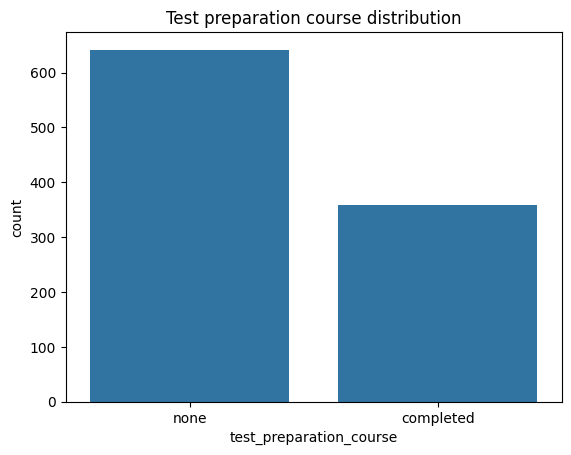

In [38]:
sns.countplot(x='test_preparation_course', data=df) 
plt.title('Test preparation course distribution')
plt.show()

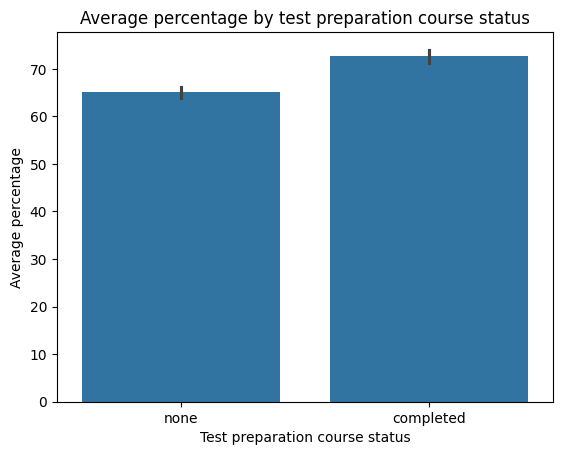

In [39]:
sns.barplot(x='test_preparation_course', y='percentage', data=df)
plt.title('Average percentage by test preparation course status')
plt.xlabel('Test preparation course status')
plt.ylabel('Average percentage')
plt.show()

completing course is beneficial to get higher marks.

### Checking Outliers

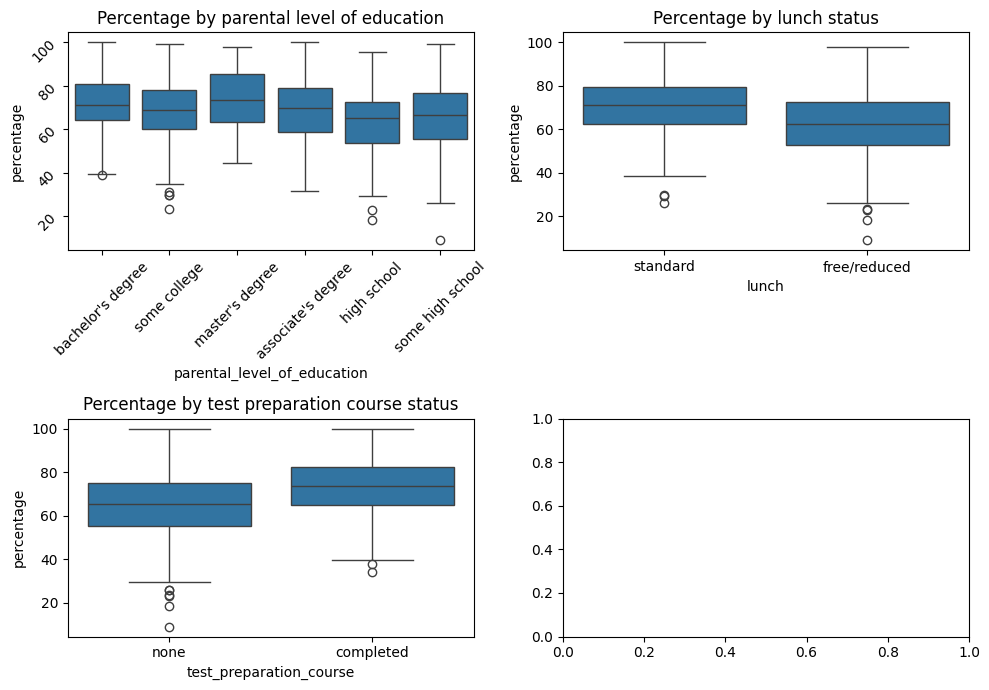

In [49]:
fig, axes = plt.subplots(2,2, figsize=(10,7))
sns.boxplot(x='parental_level_of_education', y='percentage', data=df, ax=axes[0,0])
axes[0,0].set_title('Percentage by parental level of education')
axes[0,0].tick_params(rotation=45)
sns.boxplot(x='lunch', y='percentage', data=df, ax=axes[0,1])
axes[0,1].set_title('Percentage by lunch status')
sns.boxplot(x='test_preparation_course', y='percentage', data=df, ax=axes[1,0])
axes[1,0].set_title('Percentage by test preparation course status')
plt.tight_layout()
plt.show()

### using pairplot

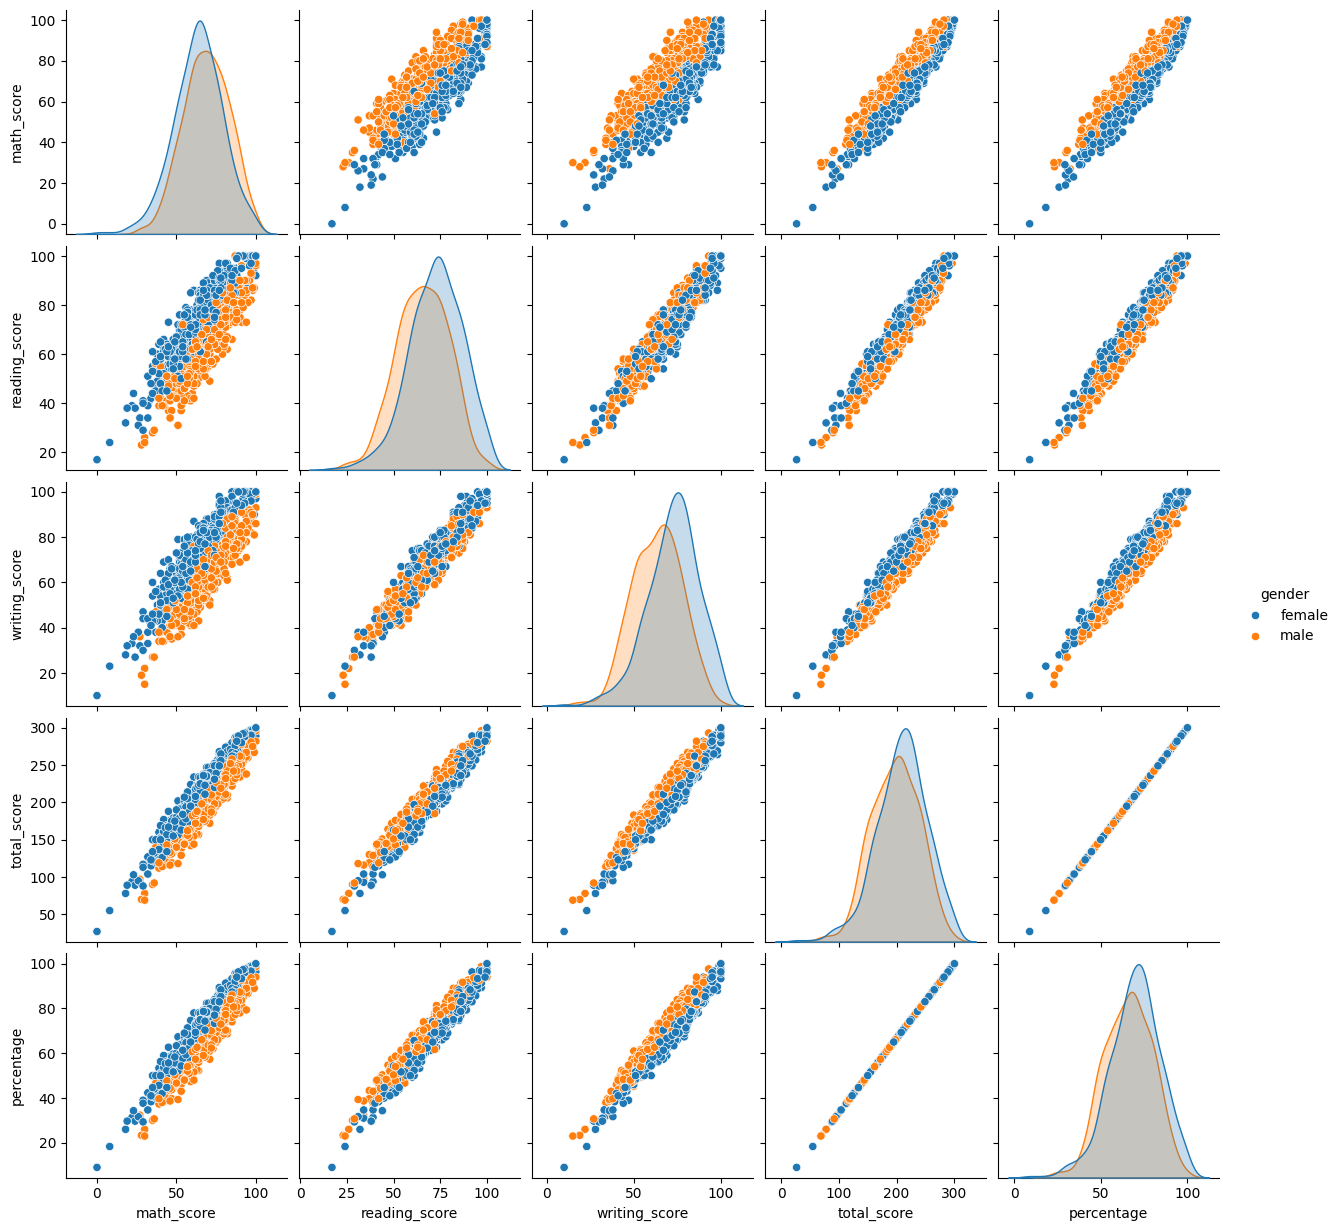

In [51]:
sns.pairplot(df,hue='gender')
plt.show()

linear relationship

### CONCLUSION

- Student's performance is related to every features.
- Female students perform better than male.
- Finishing Preparation course is imp.
- Higher Parent's education, higher will be the student performance.
- Student who belongs to race group E perfomes well than other.